# Cross trait analysis
This notebook performs cross-trait analysis to investigate relationships between multiple traits. It loads processed data, computes comparisons or associations across traits, and presents the results through visualizations. The workflow enables users to identify shared patterns, correlations, or differences between traits in an efficient and interpretable way.

In [0]:
%pip install networkx

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import yaml
import pandas as pd
CONFIG_PATH = "/Volumes/bmqg/default_bronze/fatemeh/config_mixed.yaml"

with open(CONFIG_PATH, "r") as f:
    CONFIG = yaml.safe_load(f)

GWAS_TABLE = CONFIG["data"]["gwas_table_newharvested"]
TAGLO_TABLE = CONFIG["paths"]["TAGLO_TABLE"]

PHENO_PATH = CONFIG["paths"]["aroma_matrix_newharvested"]
pheno = pd.read_csv(PHENO_PATH)

print("Phenotype shape:", pheno.shape)

Phenotype shape: (95, 39)


In [0]:
import sys

module_path = "/Volumes/bmqg/default_bronze/fatemeh/final_project/modules"

if module_path not in sys.path:
    sys.path.append(module_path)

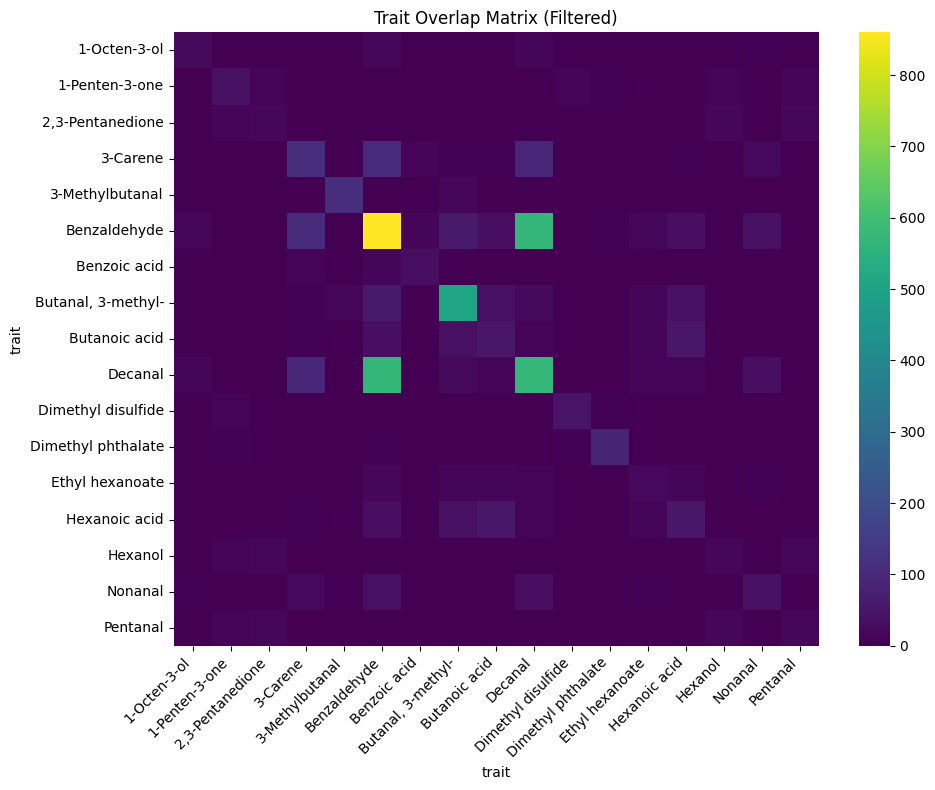

/Volumes/bmqg/default_bronze/fatemeh/final_project/modules/cross_trait_signals.py:179: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


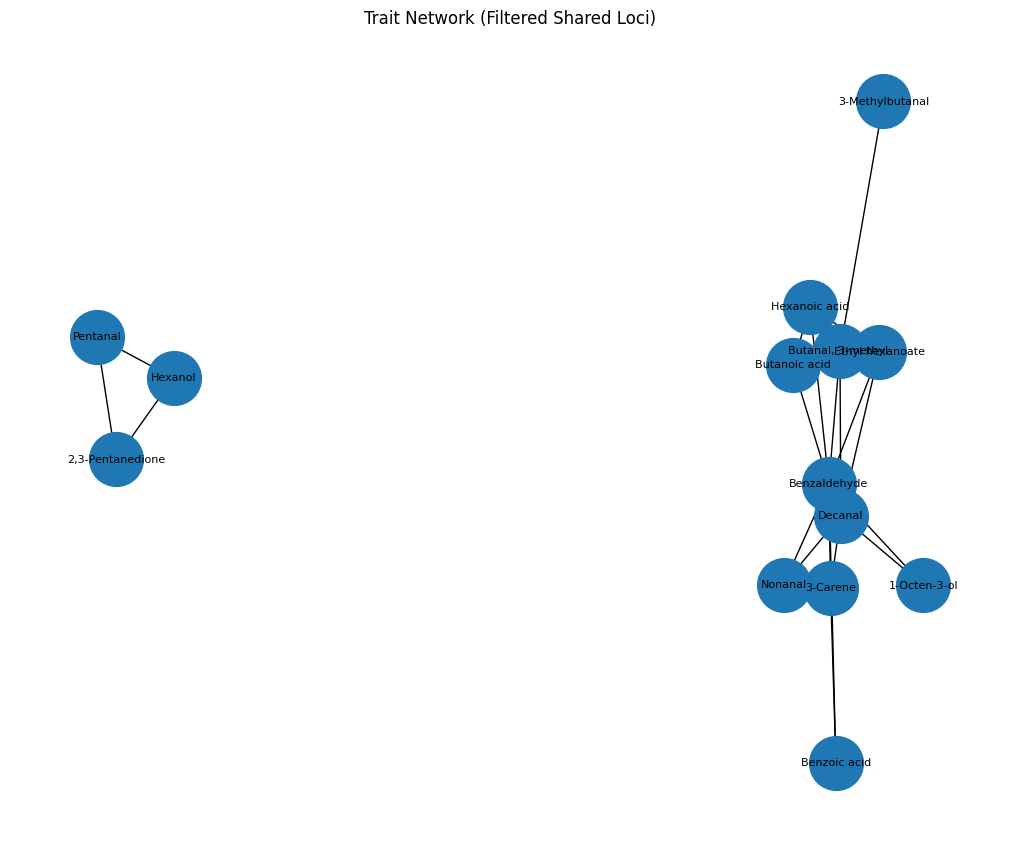

In [0]:
import importlib
import cross_trait_signals

importlib.reload(cross_trait_signals)

from cross_trait_signals import (
    plot_trait_overlap_heatmap,
    plot_trait_network,
    detect_communities,
    community_summary
)
from shared_signal import get_shared_signals

shared = get_shared_signals(
    spark=spark,
    gwas_table=GWAS_TABLE,
    p_thresh=1e-6
)
# plot
plot_trait_overlap_heatmap(shared)
plot_trait_network(shared, min_overlap=10)


# communities
comm_df = detect_communities(shared)

# save
comm_df.to_csv("/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/trait_communities.csv", index=False)

# loci per community
summary = community_summary(shared, comm_df)
summary.to_csv("/Volumes/bmqg/default_bronze/fatemeh/final_project/csv_outputs_newharvested/community_loci.csv", index=False)

The genetic architecture of aroma traits differs between new and old harvested potato, where early-stage samples show more trait-specific regulation, while mature samples exhibit a highly interconnected genetic network.